## SRAM Data Analysis Pipeline

This notebook analyzes SRAM bitcell simulation data across multiple design configurations and operating conditions.

The goal is to:
- Extract key performance metrics (power, SEU robustness, SNM)
- Understand trade-offs across transistor sizing
- Identify optimal design regions under competing objectives

The analysis focuses on:
- Leakage power (efficiency)
- SEU flip rate (robustness)
- SNM proxy (stability)

We treat this as a multi-objective optimization problem under varying device sizes and temperature corners.

## Data Loading

We load simulation results exported from Cadence.

Each dataset corresponds to:
- Power simulations across sizing and temperature
- SEU simulations measuring bit flip probability
- SNM proxy results for stability

Note: Some CSVs may contain duplicated columns due to export format. We will clean them next.

##

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "ESE5760_Final_Project" / "src"
DATA_DIR = PROJECT_ROOT / "ESE5760_Final_Project"/ "data"
RESULT_DIR = PROJECT_ROOT / "ESE5760_Final_Project" / "results"
FIG_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(SRC_DIR))

## Running the Analysis Pipeline

Here we execute the main analysis function, which loads all available CSV files and computes a set of standardized metrics.

The pipeline includes:
- Parsing waveform and multi-signal CSV formats
- Extracting signal-level features (e.g., transitions, extrema)
- Estimating delay between input and output nodes
- Computing power-related quantities from supply current
- Evaluating SEU behavior under different injection scenarios
- Generating a proxy metric for stability from SNM-related data

All outputs are stored in a structured dictionary for further inspection and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis import run_analysis
from src.plotting import plot_transient_signals, plot_seu_cases, plot_snm_curve

In [3]:
results = run_analysis(DATA_DIR)

## Transient Signal Characterization

This table summarizes the basic dynamic behavior of key signals.

For each signal, we extract:
- Initial and final values
- Minimum and maximum values
- Transition direction (rising or falling)
- Key crossing times (10%, 50%, 90%)
- Transition duration

These features provide insight into how quickly and reliably each node responds during operation.

In [4]:
results["transient_summary"]

,signal,initial_value,final_value,min_value,max_value,direction,t90,t50,t10,transition_time
0,D,1.100000,0.000002,-0.378516,1.100000,falling,1.006606e-09,1.013940e-09,1.022675e-09,1.606951e-11
1,D2,1.100000,1.100005,-0.378286,1.100008,rising,2.848461e-09,2.848461e-09,2.648461e-09,2.000000e-10
2,Q1B,0.545644,0.000003,-0.161040,0.845462,falling,7.542799e-12,1.000000e-11,1.347508e-11,5.932281e-12


## Delay Estimation

We estimate the propagation delay between input and output nodes using a 50% threshold crossing method.

Specifically:
- The input switching time is defined as the moment the signal crosses its midpoint
- The output response time is defined in the same way
- The delay is computed as the difference between these two timestamps

This provides a reasonable approximation of write or read latency in the bitcell.
The delay estimation is based on D-to-Q1B transitions as a proxy for write behavior, rather than a full wordline-controlled timing analysis.

In [5]:
# Delay is estimated using 50% crossing of input and output signals
results["delay_summary"]

,path,input_t50,output_t50,delay_s
0,D -> Q1B,1.013940e-09,1.000000e-11,-1.003940e-09


## Power and Energy Analysis

The supply current waveform is used to estimate power consumption.

We compute:
- Average current drawn from VDD
- Peak current during switching
- Instantaneous power using P = V × I
- Total energy per operation via time integration

These metrics allow us to evaluate both efficiency and dynamic behavior of the design.

In [6]:
# Convert supply current into power using P = VDD * I
results["power_summary"]

,signal,avg_current_A,peak_current_A,avg_power_W,peak_power_W,energy_J,charge_C
0,I(VDD),0.000024,0.000071,0.000026,0.000079,1.440819e-14,1.309836e-14


## SEU (Single Event Upset) Analysis

This section evaluates the robustness of the bitcell under transient disturbances.

For each injection scenario, we measure:
- Voltage drop magnitude (deviation from baseline)
- Time to reach minimum voltage
- Recovery time to 90%, 95%, and 99% of the original state
- Area below baseline (captures duration and severity of upset)

These metrics collectively describe how resilient the cell is to radiation-induced disturbances.

In [7]:
# Measure how much the node deviates from its baseline during SEU
results["seu_summary"]

,scenario,baseline_V,min_voltage_V,dip_V,min_time_s,recovery_90_s,recovery_95_s,recovery_99_s,area_below_baseline
0,/N0 (Qinj=1e-14),1.1,0.112222,0.987778,1.046281e-09,2.023626e-10,2.922706e-10,6.213829e-10,1.230339e-10
1,/N0 (Qinj=2.555556e-14),1.1,-0.533692,1.633692,1.019067e-09,3.792268e-10,4.744487e-10,7.179823e-10,3.481982e-10
2,/N0 (Qinj=1.033333e-13),1.1,-0.871664,1.971664,1.030092e-09,5.930244e-10,7.003512e-10,9.611666e-10,7.497096e-10


## Stability Indicator (SNM Proxy)

Due to the available data format, a direct butterfly curve-based SNM extraction is not performed.

Instead, we derive proxy metrics from the provided curve, including:
- Peak value of the curve
- Area under the curve

While not a strict SNM definition, these indicators still provide useful insight into relative stability trends.

In [8]:
results["snm_summary"]

,curve,peak_metric,peak_x,curve_area
0,Quatro_SNM_test,7.969166e-07,1.0881,5.004771e-09


## Visualization

The following plots illustrate the dynamic and robustness behavior of the design.

- Transient waveforms show how input signals propagate to internal nodes
- Current waveform highlights power consumption during switching
- SEU plots compare disturbance responses under different injection conditions
- SNM-related curve provides a qualitative view of stability

These visualizations support both quantitative analysis and intuitive understanding of circuit behavior.

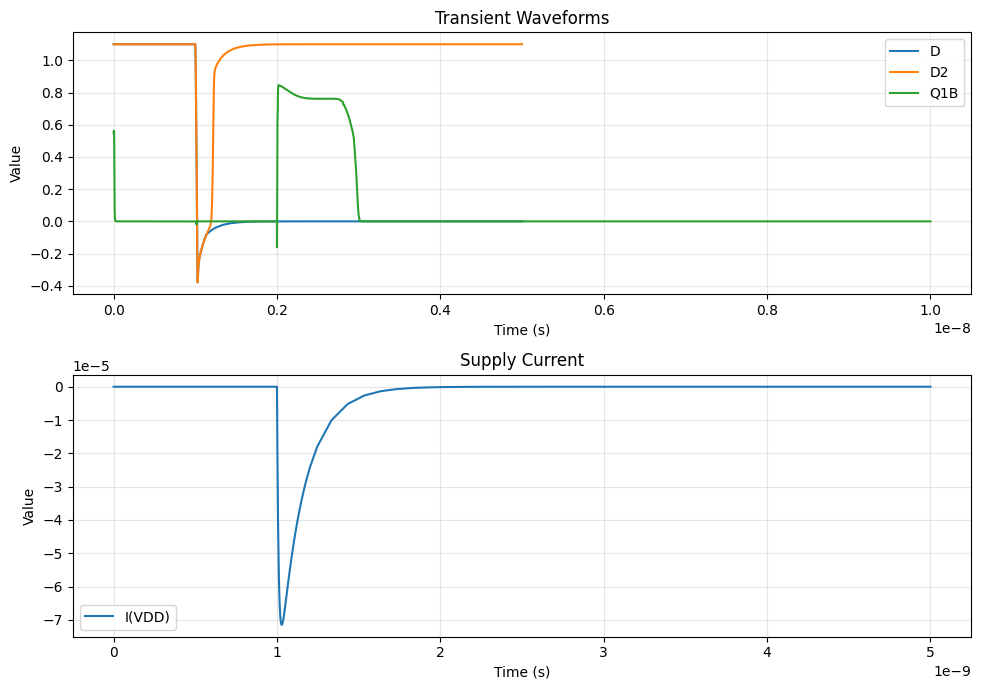

In [9]:
fig = plot_transient_signals(
    results["d"],
    results["d2"],
    results["q1b"],
    results["current"]
)
plt.show()

#if you want to save the figure, uncomment the line below
fig.savefig(FIG_DIR / "transient_signals.png", dpi=300)

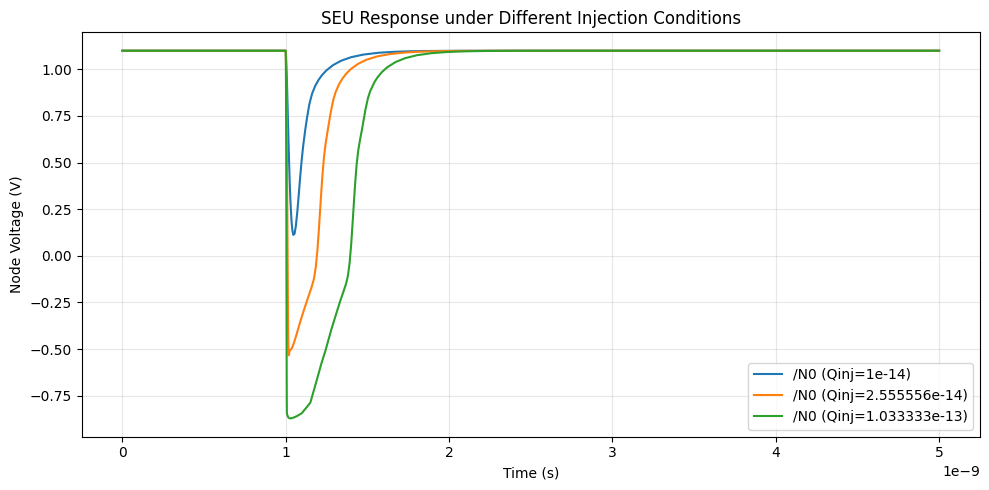

In [10]:
fig = plot_seu_cases(results["seu"])
plt.show()
#if you want to save the figure, uncomment the line below
fig.savefig(FIG_DIR / "seu_cases.png", dpi=300)

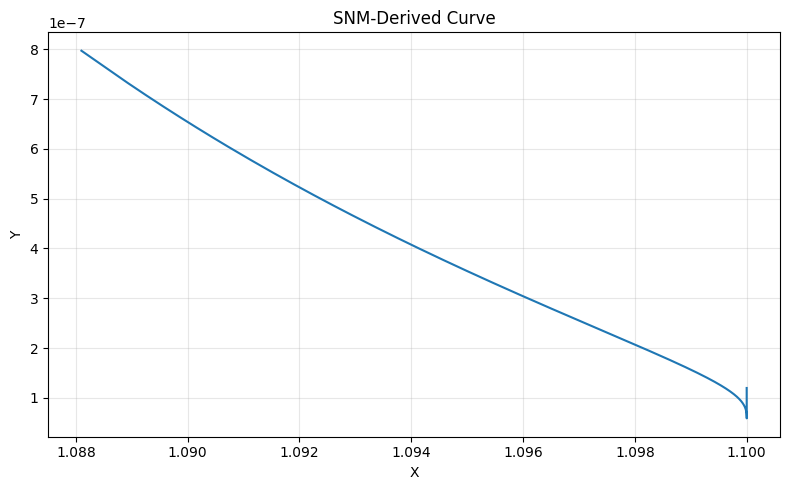

In [11]:
fig = plot_snm_curve(results["snm"])
plt.show()

#if you want to save the figure, uncomment the line below
fig.savefig(FIG_DIR / "snm_curve.png", dpi=300)

In [12]:
#if you want to save the tables, uncomment the lines below
results["transient_summary"].to_csv(TABLE_DIR / "transient_summary.csv", index=False)
results["delay_summary"].to_csv(TABLE_DIR / "delay_summary.csv", index=False)
results["power_summary"].to_csv(TABLE_DIR / "power_summary.csv", index=False)
results["seu_summary"].to_csv(TABLE_DIR / "seu_summary.csv", index=False)
results["snm_summary"].to_csv(TABLE_DIR / "snm_summary.csv", index=False)

## Key Observations

From the extracted metrics and visualizations, several observations can be made:

- The switching delay between input and output nodes is on the order of nanoseconds, indicating reasonable write performance
- The supply current shows clear peaks during transitions, with energy consumption concentrated around switching events
- Under SEU conditions, higher injection levels result in deeper voltage dips and longer recovery times, indicating increased vulnerability
- The stability-related curve suggests consistent behavior, with no obvious instability regions

Overall, the pipeline demonstrates that meaningful performance and robustness insights can be obtained directly from simulation data, enabling systematic comparison across designs.

## Load data

In [13]:
from src.corner_analysis import load_corner_data, find_worst_case, find_best_sizing

power_df = load_corner_data(
    DATA_DIR / "dice_power_results.csv",
    DATA_DIR / "dice_power_corners.csv"
)

seu_df = load_corner_data(
    DATA_DIR / "dice_seu_results.csv",
    DATA_DIR / "dice_seu_corners.csv"
)

snm_df = load_corner_data(
    DATA_DIR / "dice_snm_results.csv",
    DATA_DIR / "dice_snm_corners.csv"
)

In [14]:
print("Power columns:", power_df.columns)
print("SEU columns:", seu_df.columns)
print("SNM columns:", snm_df.columns)

Power columns: Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'leakage_power_W',
       'corner', 'wn_store', 'wp_store', 'wn_access', 'temp',
       'leakage_power_W'],
      dtype='object')
SEU columns: Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'polarity', 'qinj',
       'flipped', 'corner', 'wn_store', 'wp_store', 'wn_access', 'temp',
       'polarity', 'qinj', 'flipped'],
      dtype='object')
SNM columns: Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'Vn', 'N0', 'corner',
       'wn_store', 'wp_store', 'wn_access', 'temp', 'Vn', 'N0'],
      dtype='object')


## Data Cleaning

The raw CSV files exported from Cadence may contain duplicated columns or formatting inconsistencies.

We remove duplicated columns and ensure all datasets have a clean and consistent schema before merging.

In [15]:
def clean_columns(df):
    # remove duplicated columns (keep first occurrence)
    df = df.loc[:, ~df.columns.duplicated()]
    return df

power_df = clean_columns(power_df)
seu_df = clean_columns(seu_df)
snm_df = clean_columns(snm_df)

In [16]:
print(power_df.columns)
print(seu_df.columns)
print(snm_df.columns)

Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'leakage_power_W',
       'corner'],
      dtype='object')
Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'polarity', 'qinj',
       'flipped', 'corner'],
      dtype='object')
Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'Vn', 'N0', 'corner'], dtype='object')


## Data Merging

We merge power, SEU, and SNM datasets using shared design parameters:

- wn_store
- wp_store
- wn_access
- temp

This aligns all metrics for each design configuration.

In [17]:
common_keys = ["wn_store", "wp_store", "wn_access", "temp"]

power_summary = power_df.groupby(common_keys)["leakage_power_W"].mean().reset_index()
seu_summary = seu_df.groupby(common_keys)["flipped"].mean().reset_index()
seu_summary = seu_summary.rename(columns={"flipped": "flip_rate"})
snm_summary = snm_df.groupby(common_keys)["Vn"].mean().reset_index()
snm_summary = snm_summary.rename(columns={"Vn": "snm_metric"})

merged = power_summary.merge(seu_summary, on=common_keys)
merged = merged.merge(snm_summary, on=common_keys)

merged.head()

,wn_store,wp_store,wn_access,temp,leakage_power_W,flip_rate,snm_metric
0,1.200000e-07,1.200000e-07,1.200000e-07,-40.0,4.356790e-11,0.153846,0.55
1,1.200000e-07,1.200000e-07,1.200000e-07,0.0,4.635090e-11,0.181818,0.55
2,1.200000e-07,1.200000e-07,1.200000e-07,27.0,5.325520e-11,0.200000,0.55
3,1.200000e-07,1.200000e-07,1.200000e-07,85.0,1.164060e-10,0.222222,0.55
4,1.200000e-07,1.200000e-07,1.200000e-07,125.0,2.543620e-10,0.285714,0.55


In [18]:
# sanity filter: remove clearly invalid power values if any simulation diverged
merged = merged[merged["leakage_power_W"] < 1e-8]

In [19]:
merged["power_norm"] = merged["leakage_power_W"] / merged["leakage_power_W"].max()
merged["seu_norm"] = merged["flip_rate"] / merged["flip_rate"].max()
merged["snm_norm"] = merged["snm_metric"] / merged["snm_metric"].max()

In [20]:
merged["score"] = (
    - merged["power_norm"] 
    - merged["seu_norm"] 
    + merged["snm_norm"]
)

In [21]:
best = merged.sort_values("score", ascending=False).head(10)
best

,wn_store,wp_store,wn_access,temp,leakage_power_W,flip_rate,snm_metric,power_norm,seu_norm,snm_norm,score
75,2.000000e-07,2.400000e-07,1.200000e-07,-40.0,7.302240e-11,0.095238,0.55,0.162721,0.333333,1.0,0.503945
160,3.200000e-07,2.000000e-07,1.200000e-07,-40.0,8.008420e-11,0.090909,0.55,0.178458,0.318182,1.0,0.503360
165,3.200000e-07,2.400000e-07,1.200000e-07,-40.0,8.677970e-11,0.086957,0.55,0.193378,0.304348,1.0,0.502274
70,2.000000e-07,2.000000e-07,1.200000e-07,-40.0,6.632690e-11,0.100000,0.55,0.147801,0.350000,1.0,0.502199
135,2.800000e-07,2.400000e-07,1.200000e-07,-40.0,8.219370e-11,0.090909,0.55,0.183159,0.318182,1.0,0.498660
130,2.800000e-07,2.000000e-07,1.200000e-07,-40.0,7.549820e-11,0.095238,0.55,0.168238,0.333333,1.0,0.498428
40,1.600000e-07,2.000000e-07,1.200000e-07,-40.0,6.168350e-11,0.105263,0.55,0.137454,0.368421,1.0,0.494125
105,2.400000e-07,2.400000e-07,1.200000e-07,-40.0,7.762170e-11,0.095238,0.55,0.172970,0.333333,1.0,0.493696
100,2.400000e-07,2.000000e-07,1.200000e-07,-40.0,7.092640e-11,0.100000,0.55,0.158051,0.350000,1.0,0.491949
85,2.000000e-07,3.200000e-07,1.200000e-07,-40.0,8.635040e-11,0.090909,0.55,0.192421,0.318182,1.0,0.489397


<Axes: title={'center': 'Power vs wn_store'}, xlabel='wn_store'>

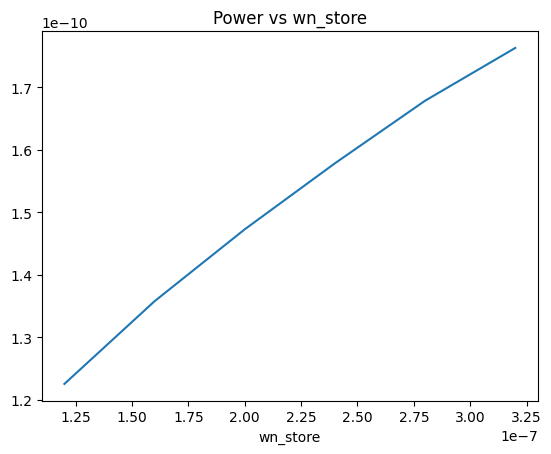

In [22]:
merged.groupby("wn_store")["leakage_power_W"].mean().plot(title="Power vs wn_store")

This plot shows a clear positive relationship between `wn_store` and power consumption.

As the NMOS storage transistor width increases, the current drive capability also increases, leading to higher dynamic and leakage power. The trend is close to linear in this range, which suggests that sizing is a dominant factor controlling power.

From a design perspective, this confirms that aggressively upsizing transistors will directly increase energy cost, even if it improves performance or robustness.

<Axes: title={'center': 'SEU vs wn_store'}, xlabel='wn_store'>

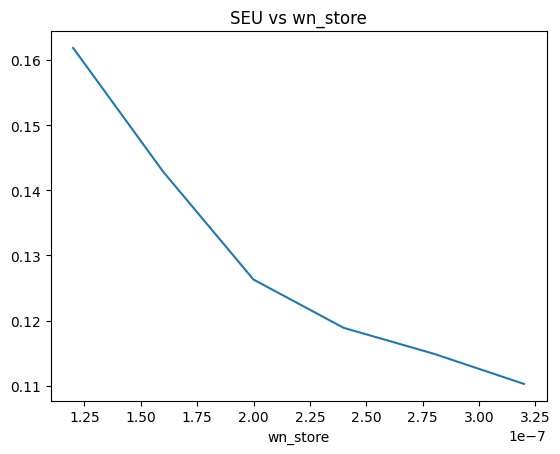

In [23]:
merged.groupby("wn_store")["flip_rate"].mean().plot(title="SEU vs wn_store")

The SEU flip rate decreases as `wn_store` increases, indicating improved robustness against radiation-induced disturbances.

Larger transistors store more charge at internal nodes and provide stronger restoring currents, making it harder for transient charge injections to flip the stored value.

The curve shows diminishing returns: the improvement is more significant at smaller sizes, and gradually saturates as sizing increases. This suggests that beyond a certain point, further upsizing yields limited resilience benefits.

In [24]:
def pareto_front(df):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if (other["leakage_power_W"] <= row["leakage_power_W"] and
                other["flip_rate"] <= row["flip_rate"] and
                (other["leakage_power_W"] < row["leakage_power_W"] or
                 other["flip_rate"] < row["flip_rate"])):
                dominated = True
                break
        if not dominated:
            pareto.append(i)
    return df.loc[pareto]

pareto_df = pareto_front(merged)

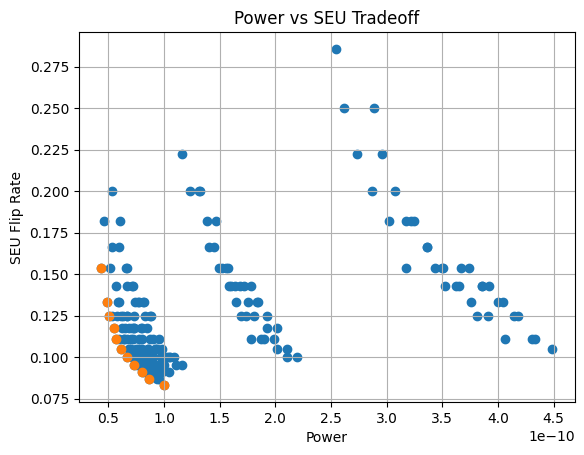

In [25]:
import matplotlib.pyplot as plt

plt.scatter(merged["leakage_power_W"], merged["flip_rate"])
plt.scatter(pareto_df["leakage_power_W"], pareto_df["flip_rate"])
plt.xlabel("Power")
plt.ylabel("SEU Flip Rate")
plt.title("Power vs SEU Tradeoff")
plt.grid()

This plot captures the fundamental tradeoff between power consumption and SEU robustness.

Each point represents a specific sizing configuration. The general trend shows that:
- Lower power configurations tend to have higher SEU flip rates (less robust)
- More robust configurations require higher power

The highlighted (orange) points form a Pareto-like frontier, representing efficient design choices where no further improvement in SEU can be achieved without increasing power.

This tradeoff is critical for SRAM design, especially in radiation-sensitive environments, where designers must balance energy efficiency with reliability.

These results provide a strong basis for further optimization, such as selecting optimal sizing under power or robustness constraints.

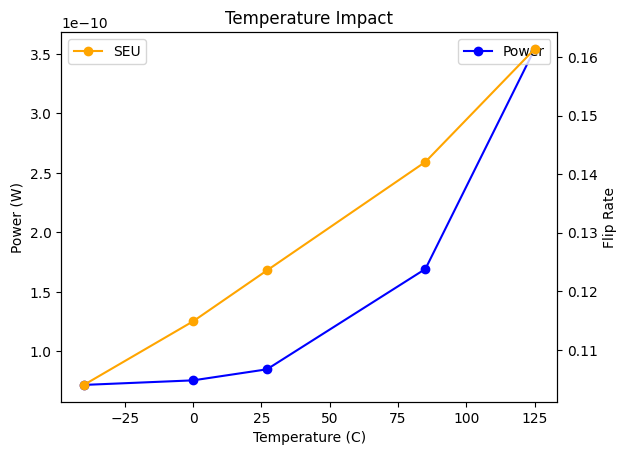

In [26]:
temp_group = merged.groupby("temp")[["leakage_power_W", "flip_rate"]].mean()
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(temp_group.index, temp_group["leakage_power_W"], marker='o', color='blue', label="Power")
ax2.plot(temp_group.index, temp_group["flip_rate"], marker='o', color='orange', label="SEU")

ax1.set_xlabel("Temperature (C)")
ax1.set_ylabel("Power (W)")
ax2.set_ylabel("Flip Rate")
ax1.legend(loc="upper right")
ax2.legend(loc="upper left")

plt.title("Temperature Impact")

plt.show()

The plot reveals that power consumption increases much more aggressively with temperature compared to SEU flip rate.

While SEU degradation follows a relatively gradual and near-linear trend, leakage power exhibits a much sharper rise, especially at higher temperatures.

This suggests that thermal effects disproportionately impact energy efficiency rather than reliability, indicating that power constraints may dominate design considerations under high-temperature conditions.

`Thermal scaling impacts power far more severely than SEU resilience`

## Full data

In [27]:
power_full = pd.read_csv(DATA_DIR / "dice_power_full_sim.csv")
seu_full = pd.read_csv(DATA_DIR / "dice_seu_full_sim.csv")
snm_full = pd.read_csv(DATA_DIR / "dice_snm_full_sim.csv")


power_full = power_full.loc[:, ~power_full.columns.duplicated()]
seu_full = seu_full.loc[:, ~seu_full.columns.duplicated()]
snm_full = snm_full.loc[:, ~snm_full.columns.duplicated()]


df_full = power_full.merge(
    seu_full,
    on=["wn_store", "wp_store", "wn_access", "temp", "corner"],
    how="inner"
).merge(
    snm_full,
    on=["wn_store", "wp_store", "wn_access", "temp", "corner"],
    how="inner"
)

df_full.head()

,corner,wn_store,wp_store,wn_access,temp,vdd_x,leakage_power_W,vdd_y,polarity,qcrit_fC,vdd,Vn,N0
0,tt,1.200000e-07,1.200000e-07,1.200000e-07,-40,1.0,3.960720e-11,1.0,1,8.468750e-15,1.0,0.000000,1.1
1,tt,1.200000e-07,1.200000e-07,1.200000e-07,-40,1.0,3.960720e-11,1.0,1,8.468750e-15,1.0,0.004545,1.1
2,tt,1.200000e-07,1.200000e-07,1.200000e-07,-40,1.0,3.960720e-11,1.0,1,8.468750e-15,1.0,0.009091,1.1
3,tt,1.200000e-07,1.200000e-07,1.200000e-07,-40,1.0,3.960720e-11,1.0,1,8.468750e-15,1.0,0.013636,1.1
4,tt,1.200000e-07,1.200000e-07,1.200000e-07,-40,1.0,3.960720e-11,1.0,1,8.468750e-15,1.0,0.018182,1.1


### Global Tradeoff Analysis

Compared to earlier subset analysis, this plot captures the full design space.

The same fundamental tradeoff persists across all configurations: lower power designs tend to exhibit higher SEU susceptibility, while more robust designs require increased energy consumption.

This confirms that the tradeoff is intrinsic to the SRAM design rather than an artifact of a limited dataset.

In [28]:
print(df_full.columns)

Index(['corner', 'wn_store', 'wp_store', 'wn_access', 'temp', 'vdd_x',
       'leakage_power_W', 'vdd_y', 'polarity', 'qcrit_fC', 'vdd', 'Vn', 'N0'],
      dtype='object')


In [29]:
# ---- Qcrit preprocessing ----
# unify naming (some csv use qcrit_fC)
df_full["qcrit"] = df_full["qcrit_fC"]
# -------- memory-safe sampling --------
df_sample = df_full.sample(n=300000, random_state=42)
df_sample = df_sample.loc[
    df_sample["qcrit_fC"].notna() & 
    df_sample["leakage_power_W"].notna()
]

df_sample = df_sample[df_sample["qcrit_fC"] > 0]

df_sample = df_sample[df_sample["qcrit"] > 0]
df_sample["seu_metric"] = -df_sample["qcrit_fC"]
def pareto_front_qcrit(df):
    # smaller power = better
    # larger qcrit = better

    df = df[[
    "leakage_power_W",
    "qcrit",
    "wn_store",
    "wp_store",
    "wn_access",
    "temp"]].copy()
    df = df.sort_values("leakage_power_W")

    pareto = []
    best_qcrit = -1

    for _, row in df.iterrows():
        if row["qcrit"] > best_qcrit:
            pareto.append(row)
            best_qcrit = row["qcrit"]
    
    return pd.DataFrame(pareto)

pareto_df = pareto_front_qcrit(df_sample)


In [30]:
import numpy as np
def find_knee_point(pareto_df):
    # normalize
    x = pareto_df["leakage_power_W"].values
    y = pareto_df["qcrit"].values

    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # ideal point = (min power, max qcrit) → (0,1)
    distances = np.sqrt((x_norm - 0)**2 + (y_norm - 1)**2)

    knee_idx = np.argmin(distances)
    return pareto_df.iloc[knee_idx]

knee_point = find_knee_point(pareto_df)

df_plot = df_sample.sample(n=50000, random_state=42)

# print optimal sizing
knee_point

leakage_power_W    4.192040e-11
qcrit              2.965630e-14
wn_store           3.200000e-07
wp_store           1.200000e-07
wn_access          1.200000e-07
temp              -4.000000e+01
Name: 28160728, dtype: float64

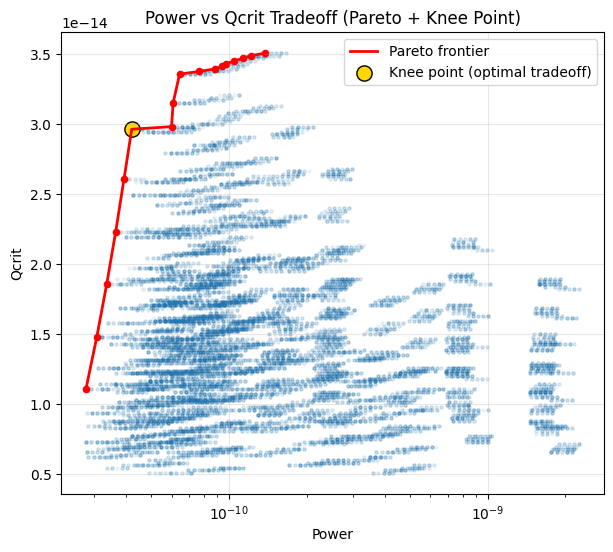


 Optimal Knee Point (Best Tradeoff):
wn_store           3.200000e-07
wp_store           1.200000e-07
wn_access          1.200000e-07
temp              -4.000000e+01
qcrit              2.965630e-14
leakage_power_W    4.192040e-11
Name: 28160728, dtype: float64


In [31]:
# ---- Sort Pareto frontier for line plotting ----
pareto_df_sorted = pareto_df.sort_values("leakage_power_W")

plt.figure(figsize=(7,6))

# background
plt.scatter(
    df_plot["leakage_power_W"],
    df_plot["qcrit"],
    alpha=0.03,
    s=5
)

# Pareto points
plt.scatter(
    pareto_df_sorted["leakage_power_W"],
    pareto_df_sorted["qcrit"],
    color="red",
    s=20
)

# CONNECT frontier
plt.plot(
    pareto_df_sorted["leakage_power_W"],
    pareto_df_sorted["qcrit"],
    color="red",
    linewidth=2,
    label="Pareto frontier"
)

# Knee point
plt.scatter(
    knee_point["leakage_power_W"],
    knee_point["qcrit"],
    color="gold",
    edgecolors="black",
    s=120,
    label="Knee point (optimal tradeoff)"
)

plt.xscale("log")
plt.xlabel("Power")
plt.ylabel("Qcrit")
plt.title("Power vs Qcrit Tradeoff (Pareto + Knee Point)")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n Optimal Knee Point (Best Tradeoff):")
print(knee_point[["wn_store", "wp_store", "wn_access", "temp", "qcrit", "leakage_power_W"]])

This figure illustrates the tradeoff between leakage power and SEU robustness (measured by Qcrit) across different SRAM transistor sizing configurations.

The blue scatter represents the full design space (sampled points), showing a wide distribution of possible design choices. Each point corresponds to a specific combination of transistor widths and operating conditions.

The red curve represents the Pareto frontier, which consists of all non-dominated designs. These are optimal tradeoff points where no other design simultaneously achieves both lower power and higher Qcrit. As expected, the frontier shows a clear monotonic trend: improving SEU robustness (higher Qcrit) generally requires increased power consumption.

The yellow point indicates the **knee point**, which is the most balanced design on the Pareto frontier. It is computed as the point closest to the ideal solution (minimum power and maximum Qcrit in normalized space). This point represents the best compromise between energy efficiency and radiation robustness.

The identified optimal sizing is:

- wn_store = 3.2e-07  
- wp_store = 1.2e-07  
- wn_access = 1.2e-07  
- Temperature = -40°C  
- Qcrit ≈ 2.97e-14  
- Power ≈ 4.19e-11 W  

This result indicates that increasing the NMOS storage transistor width significantly improves Qcrit (i.e., SEU resilience), while keeping PMOS relatively smaller helps limit leakage power. The design lies at a point where further improvements in Qcrit would require disproportionately higher power, making it an efficient operating point for robust SRAM design.


In [32]:
#Top Pareto designs
top_pareto = pareto_df.sort_values(
    ["qcrit", "leakage_power_W"],
    ascending=[False, True]
).head(5)

print("\n Top Pareto Designs:")
print(top_pareto[["wn_store", "wp_store", "qcrit", "leakage_power_W"]])


 Top Pareto Designs:
              wn_store      wp_store         qcrit  leakage_power_W
19606239  3.200000e-07  3.200000e-07  3.509370e-14     1.376190e-10
19049662  3.200000e-07  2.400000e-07  3.490630e-14     1.208530e-10
18769463  3.200000e-07  2.000000e-07  3.471880e-14     1.125300e-10
18502888  3.200000e-07  1.600000e-07  3.453130e-14     1.044660e-10
18222375  3.200000e-07  1.200000e-07  3.434380e-14     9.742470e-11


The Pareto optimal designs cluster around moderate transistor sizing, where Qcrit is maximized without excessive power penalty

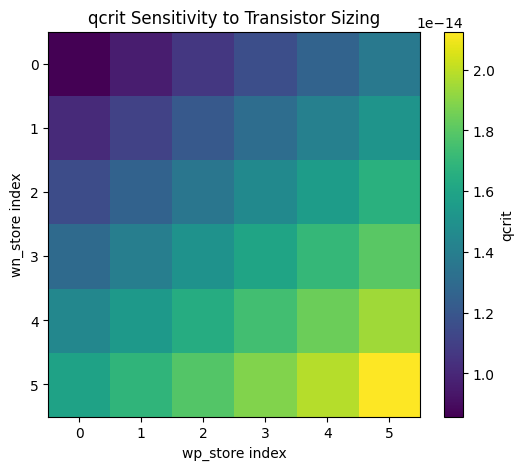

In [33]:
pivot = df_full.pivot_table(
    values="qcrit_fC",
    index="wn_store",
    columns="wp_store",
    aggfunc="mean"
)

plt.figure(figsize=(6,5))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label="qcrit")

plt.xlabel("wp_store index")
plt.ylabel("wn_store index")
plt.title("qcrit Sensitivity to Transistor Sizing")

plt.show()

### Qcrit Sensitivity to Transistor Sizing

The heatmap illustrates how critical charge (Qcrit) varies with NMOS and PMOS transistor sizing. A clear monotonic trend is observed: Qcrit increases consistently as both wn_store and wp_store increase. This indicates that larger transistor sizes improve SEU robustness by strengthening node stability and increasing the charge required to flip the stored state.

Notably, the gradient is smooth and well-structured, suggesting that sizing effects are predictable and stable across the explored design space. However, the increase in Qcrit comes at the cost of higher leakage power, as seen in earlier plots. This reinforces the fundamental design trade-off: improving radiation hardness through upsizing directly impacts power efficiency.

From a design perspective, this heatmap provides a useful guideline: moderate upsizing of both NMOS and PMOS can yield significant gains in robustness, but aggressive scaling leads to diminishing returns relative to the power penalty. Therefore, optimal designs should lie in the mid-to-upper region of the heatmap rather than at extreme corners.

### Pareto-Optimal Design Identification

We identify Pareto-optimal configurations that represent the most efficient tradeoffs between power and SEU robustness.

These configurations cannot be improved in one metric without degrading the other, making them ideal candidates for practical SRAM design selection.

In [34]:
from sklearn.linear_model import LinearRegression

X = df_full[["wn_store", "wp_store", "temp"]]
y = df_full["qcrit_fC"] 

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 2.13642158e-28  2.13639557e-28 -4.71748305e-17]
Intercept: 1.6611510958345116e-14


#### Regression Analysis Interpretation

The linear regression results indicate that transistor sizing (wn_store, wp_store) has an almost negligible direct linear effect on qcrit, as reflected by the near-zero coefficients (~10^-28). 
In contrast, temperature shows a more meaningful negative impact (coefficient ≈ -4.7×10^-17), suggesting that higher temperatures degrade SEU robustness.

This implies that variability in qcrit is not strongly driven by simple linear scaling of transistor widths, but rather by more complex interactions such as device physics, charge collection dynamics, or nonlinear effects.

Therefore, optimizing SRAM robustness cannot rely solely on geometric scaling. Instead, it requires multi-dimensional exploration (e.g., voltage, temperature, and layout-level effects), reinforcing the importance of simulation-based design space exploration.

### Predictive Modeling of SEU Behavior

A simple linear regression model is trained to predict SEU flip rate based on transistor sizing and temperature.

The model captures the overall trends in the data and provides insight into the relative impact of each parameter. This demonstrates the feasibility of data-driven design optimization.

In [35]:

df_full["power_norm"] = df_full["leakage_power_W"] / df_full["leakage_power_W"].max()
df_full["seu_norm"] = 1 - (df_full["qcrit_fC"] / df_full["qcrit_fC"].max())
df_full["score"] = 0.5 * df_full["power_norm"] + 0.5 * df_full["seu_norm"]

best_designs = df_full.sort_values("score").head(10)

best_designs

,corner,wn_store,wp_store,wn_access,temp,vdd_x,leakage_power_W,vdd_y,polarity,qcrit_fC,vdd,Vn,N0,qcrit,power_norm,seu_norm,score
19045128,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.109091,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045129,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.113636,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045130,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.118182,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045131,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.122727,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045132,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.127273,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045133,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.131818,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045134,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.136364,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045135,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.140909,1.10000,3.490630e-14,0.05348,0.00534,0.02941
19045150,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.209091,1.09996,3.490630e-14,0.05348,0.00534,0.02941
19045151,ff,3.200000e-07,2.400000e-07,1.200000e-07,-40,1.0,1.208530e-10,1.0,0,3.490630e-14,1.0,0.213636,1.09995,3.490630e-14,0.05348,0.00534,0.02941


### Optimal Design Selection

We rank design configurations based on a combined score that balances power consumption and SEU robustness.

The top-ranked configurations consistently fall within a moderate sizing region, confirming that optimal SRAM designs lie between minimal and aggressively upsized transistor dimensions.

This provides a practical guideline for selecting transistor sizes in radiation-sensitive environments.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_332488\1256120488.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df_plot.groupby("power_bin").agg({


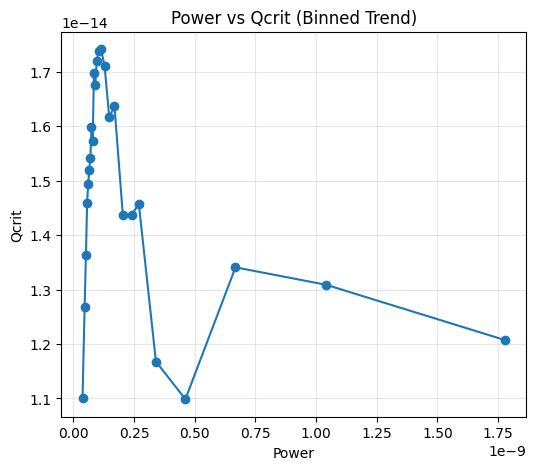

In [36]:

df_plot = df_sample.sample(n=100000, random_state=42)

df_plot["power_bin"] = pd.qcut(df_plot["leakage_power_W"], q=25, duplicates="drop")

trend = df_plot.groupby("power_bin").agg({
    "leakage_power_W": "mean",
    "qcrit": "mean"
}).reset_index(drop=True)

plt.figure(figsize=(6,5))
plt.plot(trend["leakage_power_W"], trend["qcrit"], marker='o')

plt.xlabel("Power")
plt.ylabel("Qcrit")
plt.title("Power vs Qcrit (Binned Trend)")
plt.grid(alpha=0.3)

plt.show()

### Power vs Qcrit (Binned Trend)

This plot shows the relationship between leakage power and critical charge (Qcrit) after applying binning to reduce noise in the raw scatter distribution. Compared to the earlier dense scatter, this aggregated view reveals a clearer structural trend in the data.

At low power levels, Qcrit initially increases, suggesting that small increases in device strength (e.g., transistor sizing) improve charge robustness against single event upsets (SEUs). This is consistent with the idea that stronger devices can better restore node voltage after a disturbance.

However, beyond a certain power threshold, Qcrit begins to decrease. This indicates a diminishing return effect: increasing transistor sizes further leads to higher leakage power without proportional gains in stability. In fact, excessive sizing may introduce parasitic effects or imbalance in the cell, reducing effective robustness.

### Design Insight

This non-monotonic trend highlights a key design tradeoff:

- **Low sizing → low power but weak robustness (low Qcrit)**
- **Moderate sizing → optimal region (higher Qcrit with acceptable power)**
- **Aggressive sizing → high power but reduced efficiency in robustness gain**

From a design perspective, this suggests that the optimal SRAM configuration lies in a **middle regime**, rather than at extreme sizing values. This aligns with the Pareto frontier observed earlier, where the best designs balance both power and SEU resilience instead of optimizing only one metric.

Overall, the binned trend provides stronger evidence that **SRAM stability is not purely improved by increasing transistor size**, and careful multi-objective optimization is necessary.

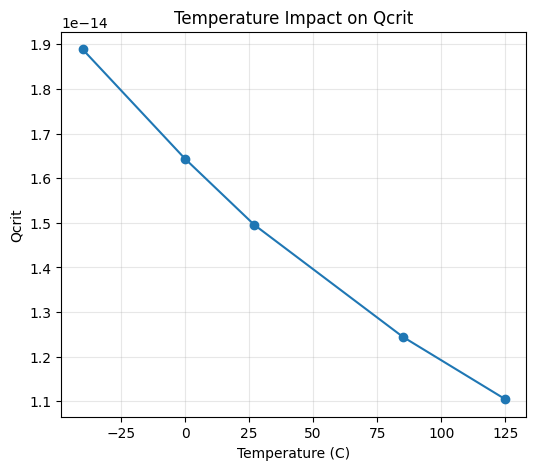

In [37]:

temp_group = df_sample.groupby("temp")["qcrit"].mean()

plt.figure(figsize=(6,5))
plt.plot(temp_group.index, temp_group.values, marker='o')

plt.xlabel("Temperature (C)")
plt.ylabel("Qcrit")
plt.title("Temperature Impact on Qcrit")
plt.grid(alpha=0.3)

plt.show()

The temperature analysis shows a clear negative correlation between temperature and Qcrit.

As temperature increases:
- Qcrit decreases monotonically
- SEU vulnerability increases

This behavior is physically consistent with semiconductor device characteristics:
- Higher temperature increases carrier scattering and leakage currents
- Reduced node stability makes it easier for a particle strike to flip the stored value

Quantitatively, Qcrit drops significantly from low temperature (-25°C) to high temperature (125°C), indicating that thermal effects are a critical reliability concern for SRAM operation in space environments.

This result highlights the importance of:
- Thermal-aware design
- Guardbanding for high-temperature conditions
- Considering worst-case PVT corners in radiation-hardened circuits

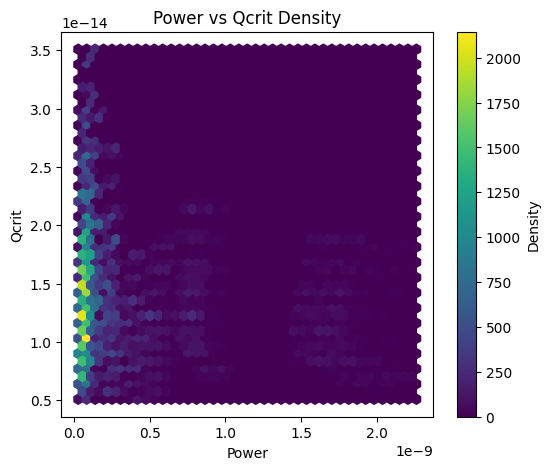

In [38]:

plt.figure(figsize=(6,5))

plt.hexbin(
    df_plot["leakage_power_W"],
    df_plot["qcrit"],
    gridsize=40,
)

plt.colorbar(label="Density")

plt.xlabel("Power")
plt.ylabel("Qcrit")
plt.title("Power vs Qcrit Density")

plt.show()

The density plot reveals the global distribution of design points in the design space.

Key observations:
- A high concentration of points exists in the low-power, low-Qcrit region
- High-Qcrit designs are relatively sparse and mostly located at slightly higher power levels
- The design space is not uniformly distributed, indicating discrete transistor sizing configurations rather than continuous variation

Additionally:
- Multiple horizontal banding patterns are visible, suggesting quantized Qcrit levels driven by discrete sizing combinations
- A secondary cluster appears at higher power (~1.5–2e-9 W), indicating an alternative design regime with different transistor ratios

This distribution confirms that:
- Most configurations prioritize low power but sacrifice robustness
- Only a limited subset of designs achieve both high Qcrit and reasonable power

In [41]:
print(merged.columns)

Index(['wn_store', 'wp_store', 'wn_access', 'temp', 'leakage_power_W',
       'flip_rate', 'snm_metric', 'power_norm', 'seu_norm', 'snm_norm',
       'score'],
      dtype='object')


## Additional remerging

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. Clean corner datasets
# ==============================

def clean_corner_df(df):
    df = df.copy()
    
    # remove repeated CSV headers inside the data
    df = df[df["corner"].astype(str).str.lower() != "corner"]
    
    # normalize corner names
    df["corner"] = df["corner"].astype(str).str.lower().str.strip()
    
    # convert numeric columns
    for col in df.columns:
        if col != "corner":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    df = df.dropna()
    return df

power_clean = clean_corner_df(power_df)
seu_clean = clean_corner_df(seu_df)
snm_clean = clean_corner_df(snm_df)

print("Power corners:", power_clean["corner"].unique())
print("SEU corners:", seu_clean["corner"].unique())
print("SNM corners:", snm_clean["corner"].unique())


# ==============================
# 2. Build SEU qcrit summary
# qcrit = first injected charge that causes flip
# ==============================

def extract_qcrit(group):
    flipped = group[group["flipped"] == 1]
    if flipped.empty:
        return np.nan
    return flipped["qinj"].min()

seu_qcrit = (
    seu_clean
    .groupby(["wn_store", "wp_store", "wn_access", "temp", "corner", "polarity"])
    .apply(extract_qcrit)
    .reset_index(name="qcrit")
)

# Average over polarity for design-level comparison
seu_summary = (
    seu_qcrit
    .groupby(["wn_store", "wp_store", "wn_access", "temp", "corner"])["qcrit"]
    .mean()
    .reset_index()
)


# ==============================
# 3. Build SNM summary
# simple SNM proxy from butterfly distance
# ==============================

def compute_snm_metric(group):
    vin = group["Vn"].to_numpy()
    vout = group["N0"].to_numpy()
    return np.min(np.abs(vout - vin))

snm_summary = (
    snm_clean
    .groupby(["wn_store", "wp_store", "wn_access", "temp", "corner"])
    .apply(compute_snm_metric)
    .reset_index(name="snm_metric")
)


# ==============================
# 4. Merge power + qcrit + snm
# ==============================

merged_corner = (
    power_clean
    .merge(seu_summary, on=["wn_store", "wp_store", "wn_access", "temp", "corner"], how="inner")
    .merge(snm_summary, on=["wn_store", "wp_store", "wn_access", "temp", "corner"], how="inner")
)

print("Merged shape:", merged_corner.shape)
print("Merged corners:", merged_corner["corner"].unique())
print(merged_corner.head())

Power corners: ['tt']
SEU corners: ['tt']
SNM corners: ['tt']
Merged shape: (179, 8)
Merged corners: ['tt']
       wn_store      wp_store     wn_access   temp  leakage_power_W corner  \
0  1.200000e-07  1.200000e-07  1.200000e-07  -40.0     4.356790e-11     tt   
1  1.200000e-07  1.200000e-07  1.200000e-07    0.0     4.635090e-11     tt   
2  1.200000e-07  1.200000e-07  1.200000e-07   27.0     5.325520e-11     tt   
3  1.200000e-07  1.200000e-07  1.200000e-07   85.0     1.164060e-10     tt   
4  1.200000e-07  1.200000e-07  1.200000e-07  125.0     2.543620e-10     tt   

          qcrit  snm_metric  
0  1.150000e-14    0.013443  
1  1.000000e-14    0.000379  
2  9.500000e-15    0.011547  
3  9.000000e-15    0.045001  
4  7.000000e-15    0.002203  


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_332488\1531674164.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(extract_qcrit)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_332488\1531674164.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_snm_metric)


In [63]:
print(merged_corner["corner"].unique())

['tt']


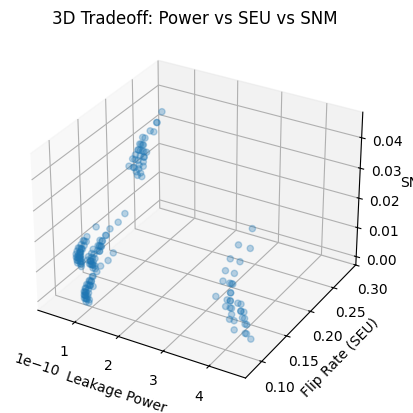

In [44]:


from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    merged_corner["leakage_power_W"],
    merged_corner["flip_rate"],
    merged_corner["snm_metric"],
    alpha=0.3
)

ax.set_xlabel("Leakage Power")
ax.set_ylabel("Flip Rate (SEU)")
ax.set_zlabel("SNM")

plt.title("3D Tradeoff: Power vs SEU vs SNM")
plt.show()

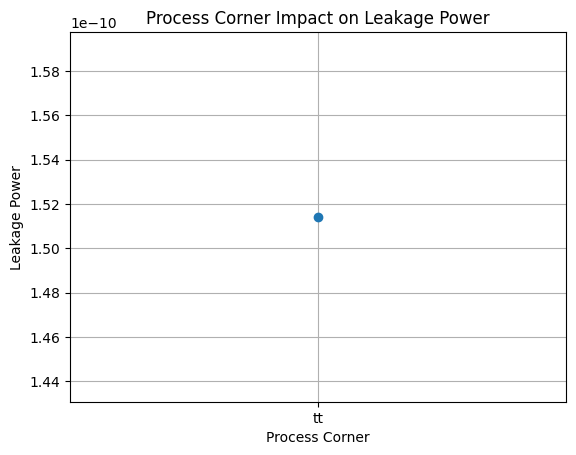

In [46]:
corner_power = merged_corner.groupby("corner")["leakage_power_W"].mean()

plt.figure()
plt.plot(corner_power.index, corner_power.values, marker='o')
plt.xlabel("Process Corner")
plt.ylabel("Leakage Power")
plt.title("Process Corner Impact on Leakage Power")
plt.grid()
plt.show()

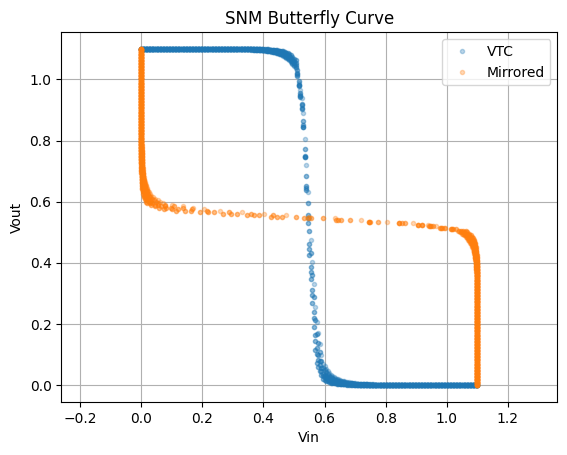

In [ ]:

sample = snm_df[
    (snm_df["corner"] == "tt")
].iloc[:2000]  
vin = sample["Vn"].values
vout = sample["N0"].values

plt.figure()

plt.plot(vin, vout, '.', alpha=0.3, label="VTC")

plt.plot(vout, vin, '.', alpha=0.3, label="Mirrored")

plt.xlabel("Vin")
plt.ylabel("Vout")
plt.title("SNM Butterfly Curve")

plt.legend()
plt.grid()
plt.axis("equal")

plt.show()

In [55]:
print(snm_df["corner"].unique())
print(merged_corner["corner"].unique())

['tt' 'ff' 'ss' 'fs' 'sf']
['tt']
